# Recurrent Neural Networks and Time Series

The [artificial neural network](ann.ipynb) makes no assumption about how its
inputs are arranged, and the [convolutional neural network](cnn.ipynb) builds in
a *spatial* inductive bias for images and gridded fields. This section
introduces the third major architecture: the **recurrent neural network (RNN)**,
a regularized neural network built to process **sequences**, above all the
time series that fill environmental science. We will:

- Define the **recurrent neural network** and distinguish it from the CNN.
- Discuss **forecasting** in the context of environmental time series.
- Define **natural language processing**, where these architectures originated.
- Understand several ML architectures used for time series prediction: the
  **vanilla RNN**, the **LSTM**, the **GRU**, and (briefly) the **transformer**.
- Discuss **inductive bias** in machine learning models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## From images to sequences

A fully connected neural network can learn a mapping from any set of input
features to an output, but it shares no weights and assumes no structure. The
CNN regularizes it for spatial data by sliding one small filter across the
whole map. The RNN applies the same trick along a different axis: it is a
**regularized neural network for sequences**, sharing one set of weights across
every *time step* instead of every pixel.

RNNs were originally developed for **natural language processing (NLP)**, the
subset of artificial intelligence focused on using machines to interpret and
understand human language. A sentence is a sequence of words, and a canonical
NLP task is: given the first few words, predict the next one. The same
machinery powers:

- **Speech recognition**: map a sound wave to the words it contains, the basis
  of voice assistants like Siri or Alexa.
- **Machine translation**: translate a sentence between languages, hard
  because word order differs and there is rarely a one-to-one mapping between
  words.

### RNNs in environmental science

In climate and environmental applications we mostly use these architectures
for **time series prediction**: modeling how an environmental system changes
over time.

- **Rainfall-runoff modeling in hydrology.** Predict the discharge of a stream
  from meteorological forcing. This is hard to do with a numerical model:
  flooding depends not just on today's precipitation but on the *past*
  precipitation, the topography of the catchment, snowpack, and more. Large
  community datasets (CAMELS, with 35 years of daily forcing and discharge for
  671 US basins, and its global successor Caravan) have enabled so-called
  catchment-independent rainfall-runoff models trained across many streams at
  once.
- **Dynamic time series modeling.** Predict a quantity like humidity that has
  a diurnal cycle with weather-driven variability on top.
- **Dynamic land cover classification.** Combine sequential models with CNNs
  to track how land cover changes over time from satellite imagery.

## Four ways to set up a forecast

The same recurrent machinery supports several problem setups, and choosing one
is the first modeling decision:

- **Sequence to sequence**: features at every time step in, a prediction at
  every time step out (e.g. meteorology in, water level out, day by day).
- **Sequence to vector**: several past time steps in, a *single* prediction
  out. The rainfall-runoff example in the [companion tutorial](rnn_tutorial.ipynb) works this way: the
  previous 365 days of meteorology predict today's discharge.
- **Vector to sequence**: one set of input features in, a sequence of future
  values out.
- **Encoder-decoder**: an **encoder** network compresses the input sequence
  into a learned **latent representation** (an encoding), and a separate
  **decoder** network unrolls that representation into the output sequence.
  This split appears all over machine learning and is useful when the output
  is a related but *different* variable from the input.

### Windowing: reshaping a time series into training samples

Whichever setup we choose, the raw data is one long continuous series, and the
model expects samples of shape (sequence length, number of features). We build
them by sliding a window along the series. Here is the idea on a toy series,
with a sequence length of three:

In [2]:
series = np.arange(6)          # a toy "time series": 0, 1, 2, 3, 4, 5
seq_len = 3

X = np.array([series[i:i + seq_len] for i in range(len(series) - seq_len)])
y = series[seq_len:]

for inputs, target in zip(X, y):
    print(f"input window {inputs} -> target {target}")

input window [0 1 2] -> target 3
input window [1 2 3] -> target 4
input window [2 3 4] -> target 5


Each input window carries its own short history, and the targets start
`seq_len` points into the series: the first three values have no complete
window before them, so the first target is the *fourth* value. Lining the
targets up this way is easy to get wrong and important to check. Deep learning
libraries provide utilities for exactly this reshaping (in TensorFlow,
`tf.keras.utils.timeseries_dataset_from_array`).

One practical note: because every window already contains its own history, the
*training* windows can be shuffled freely during training. But when evaluating
on a *test* period we keep the windows in temporal order, so the predicted
series can be compared against the observed one.

## The baseline to beat: persistence

Why is **naive forecasting** (also called **persistence forecasting**), which
simply predicts that the next value equals the current one, so hard to
outperform? Because environmental time series usually have strong
**autocorrelation in time**: if the sun rose yesterday, it will probably rise
today. Any model worth training has to beat this near-free baseline.

We can see this on a synthetic hourly "humidity" series with a diurnal cycle
plus slowly varying (red) noise:

lag-1 autocorrelation      : 0.962
persistence forecast MAE   : 2.89
climatology (mean) MAE     : 10.55


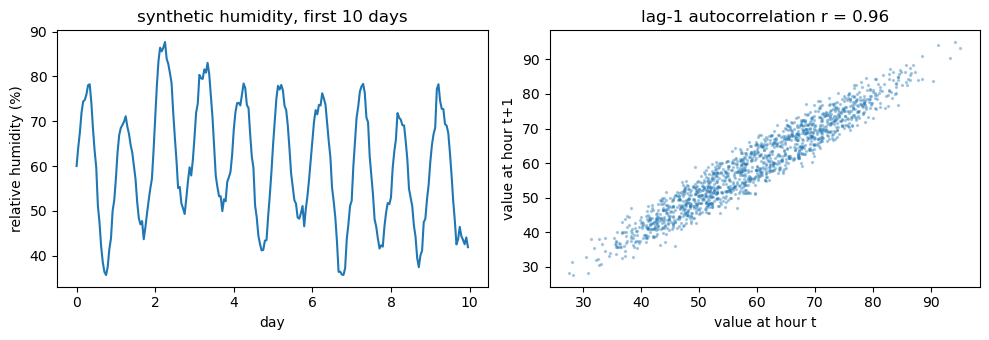

In [3]:
hours = np.arange(24 * 60)                       # 60 days, hourly
diurnal = 15 * np.sin(2 * np.pi * hours / 24)    # daily cycle
red = np.zeros(len(hours))                       # slowly varying noise
for t in range(1, len(hours)):
    red[t] = 0.95 * red[t - 1] + rng.normal(0, 2)
humidity = 60 + diurnal + red

r1 = np.corrcoef(humidity[:-1], humidity[1:])[0, 1]
mae_persistence = np.mean(np.abs(humidity[1:] - humidity[:-1]))
mae_climatology = np.mean(np.abs(humidity - humidity.mean()))

print(f"lag-1 autocorrelation      : {r1:.3f}")
print(f"persistence forecast MAE   : {mae_persistence:.2f}")
print(f"climatology (mean) MAE     : {mae_climatology:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hours[:240] / 24, humidity[:240])
ax[0].set_xlabel("day"); ax[0].set_ylabel("relative humidity (%)")
ax[0].set_title("synthetic humidity, first 10 days")
ax[1].scatter(humidity[:-1], humidity[1:], s=2, alpha=0.3)
ax[1].set_xlabel("value at hour t"); ax[1].set_ylabel("value at hour t+1")
ax[1].set_title(f"lag-1 autocorrelation r = {r1:.2f}")
plt.tight_layout(); plt.show()

Consecutive hours are almost identical (the lag-1 scatter hugs the
diagonal), so just repeating the last value is several times more accurate
than predicting the long-term mean. A model that fails to beat persistence has
effectively learned nothing beyond "tomorrow looks like today."

We saw in the CNN section that a **1-D convolution** can also process a time
series by sliding a fixed kernel of weights along the signal. It is simple and
inexpensive, but the kernel only ever sees a fixed-width window: it carries no
memory of what happened before it. For time series prediction, recurrent
architectures generally work better.

## Algorithms to process time series

We will look at four architectures, in the order they were developed: the
**vanilla RNN**, the **long short-term memory (LSTM)**, the **gated recurrent
unit (GRU)**, and the **transformer**. ("Vanilla" is machine learning slang
for the plain, original variant of a model, without extra complications.)

### The vanilla RNN

The regularization idea: use the **same update rule, with the same weights**,
at every time step. At step $t$ the network takes the current input vector
$\mathbf{x}_t$ and the previous hidden state $\mathbf{h}_{t-1}$, and produces
a new hidden state:

$$\mathbf{h}_t = \tanh\left(\mathbf{W}_h \mathbf{h}_{t-1} +
\mathbf{W}_x \mathbf{x}_t + \mathbf{b}\right)$$

If we want a prediction at step $t$, another layer maps the hidden state to
the output (followed by a softmax for classification, or nothing extra for
regression):

$$\mathbf{y}_t = \mathbf{V} \mathbf{h}_t + \mathbf{c}$$

Because $\mathbf{W}_h$, $\mathbf{W}_x$, and $\mathbf{b}$ are shared across
all time steps, the RNN is effectively learning a *single* model that it
applies at every step. This is exactly what a physical model does: the physics
of the system does not change from one time step to the next, only the state
does.

**Why the hyperbolic tangent?** The $\tanh$ activation bounds each component
of the hidden state between $-1$ and $1$. An unbounded activation like ReLU
(which ranges from 0 to infinity) can let the hidden state grow without limit
as it is fed back through the recurrence step after step, the *exploding*
regime. The demo below runs the same recurrence with the same weight matrix
under both activations:

tanh: final hidden-state norm 2.40 (bound: sqrt(10) = 3.16)
relu: final hidden-state norm 4.21e+03


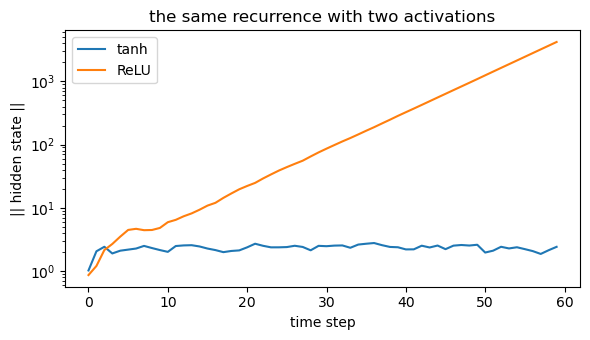

In [4]:
n_hidden, n_steps = 10, 60
W = rng.normal(0, 1, (n_hidden, n_hidden))
W *= 2.0 / np.max(np.abs(np.linalg.eigvals(W)))   # fix the spectral radius at 2

inputs = rng.normal(0, 0.5, (n_steps, n_hidden))

def run_recurrence(activation):
    h, norms = np.zeros(n_hidden), []
    for x in inputs:
        h = activation(W @ h + x)
        norms.append(np.linalg.norm(h))
    return np.array(norms)

tanh_norms = run_recurrence(np.tanh)
relu_norms = run_recurrence(lambda z: np.maximum(z, 0))

print(f"tanh: final hidden-state norm {tanh_norms[-1]:.2f} "
      f"(bound: sqrt({n_hidden}) = {np.sqrt(n_hidden):.2f})")
print(f"relu: final hidden-state norm {relu_norms[-1]:.2e}")

plt.figure(figsize=(6, 3.5))
plt.semilogy(tanh_norms, label="tanh")
plt.semilogy(relu_norms, label="ReLU")
plt.xlabel("time step"); plt.ylabel("|| hidden state ||")
plt.title("the same recurrence with two activations")
plt.legend(); plt.tight_layout(); plt.show()

With identical weights, the ReLU hidden state grows by orders of
magnitude over 60 steps while the tanh hidden state stays bounded (its norm
can never exceed $\sqrt{10} \approx 3.2$ for 10 hidden units, since every
component lies in $[-1, 1]$). This is why recurrent architectures use tanh.

### The short-term memory problem

The price of the recurrence is that vanilla RNNs **forget**: they represent
the recent past well but gradually lose information about earlier inputs. An
environmental system can have correlations on many timescales at once (daily,
seasonal, yearly), and a model that only remembers the last few steps will
miss the longer ones.

We can measure the forgetting directly: run the same input sequence twice,
perturb only the *first* input, and watch how long the difference between the
two hidden-state trajectories survives:

effect of the perturbation after step  1: 2.1e+00
effect of the perturbation after step 10: 1.1e-01
effect of the perturbation after step 30: 5.1e-05
effect of the perturbation after step 60: 4.7e-09


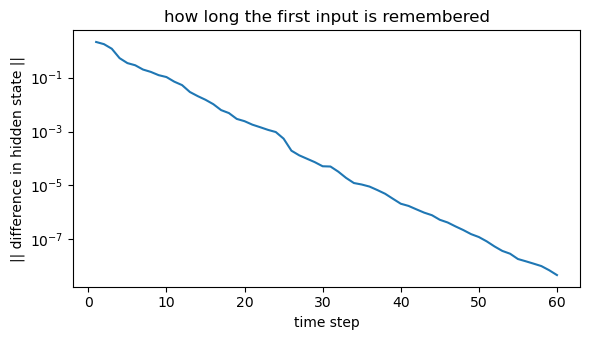

In [5]:
W_mem = rng.normal(0, 1, (n_hidden, n_hidden))
W_mem *= 0.9 / np.max(np.abs(np.linalg.eigvals(W_mem)))  # stable regime

inputs_mem = rng.normal(0, 0.5, (n_steps, n_hidden))

def run_sequence(xs):
    h, states = np.zeros(n_hidden), []
    for x in xs:
        h = np.tanh(W_mem @ h + x)
        states.append(h.copy())
    return np.array(states)

perturbed = inputs_mem.copy()
perturbed[0] += 1.0                       # change only the first input

diff = np.linalg.norm(run_sequence(perturbed) - run_sequence(inputs_mem), axis=1)
for step in (0, 9, 29, 59):
    print(f"effect of the perturbation after step {step + 1:2d}: {diff[step]:.1e}")

plt.figure(figsize=(6, 3.5))
plt.semilogy(np.arange(1, n_steps + 1), diff)
plt.xlabel("time step")
plt.ylabel("|| difference in hidden state ||")
plt.title("how long the first input is remembered")
plt.tight_layout(); plt.show()

The influence of the first input decays roughly exponentially: within a
few dozen steps it is smaller than any signal the network could use. For a
365-day input sequence, a vanilla RNN will do a much better job representing
last week's rainfall than last winter's snowpack.

## Long short-term memory (LSTM)

The **LSTM** is a more advanced recurrent architecture designed to handle
**longer-range dependencies**. It tackles the short-term memory problem by
carrying *two* states forward:

- the usual **hidden state** $\mathbf{h}_t$, tracking the immediate past, and
- a **cell state** $\mathbf{c}_t$, a longer-term memory that changes only
  slowly from step to step.

Traffic between the two is managed by three **gates**, each of which is itself
a small neural network (with its own weights) applied to the concatenation of
the previous hidden state and the current input:

$$\mathbf{f}_t = \sigma\left(\mathbf{W}_f [\mathbf{h}_{t-1},
\mathbf{x}_t] + \mathbf{b}_f\right) \qquad \text{forget gate}$$
$$\mathbf{i}_t = \sigma\left(\mathbf{W}_i [\mathbf{h}_{t-1},
\mathbf{x}_t] + \mathbf{b}_i\right) \qquad \text{input gate}$$
$$\mathbf{o}_t = \sigma\left(\mathbf{W}_o [\mathbf{h}_{t-1},
\mathbf{x}_t] + \mathbf{b}_o\right) \qquad \text{output gate}$$

The candidate update is a tanh layer, and the gates decide what the cell state
drops, what it writes, and what it exposes:

$$\tilde{\mathbf{c}}_t = \tanh\left(\mathbf{W}_c [\mathbf{h}_{t-1},
\mathbf{x}_t] + \mathbf{b}_c\right)$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} +
\mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

The **forget gate** decides which parts of the long-term memory to erase, the
**input gate** decides which parts of the new candidate to write, and the
**output gate** decides how much of the cell state shows up in the hidden
state. Because the cell state is updated *additively* (a gated copy of itself
plus a gated new term) rather than being squashed through the recurrence at
every step, information can survive across many more time steps than in the
vanilla RNN. A typical application: modeling air quality in a city, where the
prediction depends on traffic, weather, and emissions over multiple
timescales.

## Gated recurrent unit (GRU)

The **GRU** came after the LSTM and simplifies it, asking whether all that
machinery is really needed:

- a **single state vector** $\mathbf{h}_t$ (no separate cell state),
- a **single gate controller** $\mathbf{z}_t$ that handles both forgetting
  and writing (whatever is forgotten is replaced by new content),
- **no output gate**, just a reset gate $\mathbf{r}_t$ that controls how much
  of the previous state feeds into the candidate update.

It is used for the same tasks: predicting river flow rates from rainfall,
snowmelt, and temperature, for instance, where the gating helps capture the
complex dependencies.

### Which one to use?

In practice you would try the RNN and the LSTM on the same problems. The LSTM
generally works a little better because it can track dependencies on several
timescales, while the vanilla RNN forgets. But if the distant past genuinely
matters little for your problem, the simpler RNN, with far fewer weights to
learn, can do as well or better. The GRU sits in between. For the same hidden
size, the parameter counts differ by the number of internal networks each
architecture carries:

In [6]:
n_h, n_features = 10, 5      # hidden units, input features per time step

per_network = n_h * (n_h + n_features) + n_h   # weights (recurrent + input) + biases
for name, n_networks in [("vanilla RNN", 1), ("GRU", 3), ("LSTM", 4)]:
    print(f"{name:12s}: {n_networks} internal network(s) x {per_network} "
          f"= {n_networks * per_network:4d} parameters")

vanilla RNN : 1 internal network(s) x 160 =  160 parameters
GRU         : 3 internal network(s) x 160 =  480 parameters
LSTM        : 4 internal network(s) x 160 =  640 parameters


With 10 hidden units and 5 input features, one recurrent layer costs 160
parameters as a vanilla RNN, 480 as a GRU (three internal networks: reset
gate, update gate, candidate), and 640 as an LSTM (four: three gates plus the
candidate). All three then need the same small dense layer to map the final
hidden state to the prediction. More capacity to remember costs more weights
to learn, which is the trade-off to weigh against how much training data you
have.

## Attention and transformers

Most of the recent innovation in sequence modeling has gone into the
**attention mechanism**. The motivation came from machine translation:
translating a sentence is not a word-by-word lookup, because word order
differs between languages and several words of context may determine how one
word should be translated. Rather than stepping through the sequence one
element at a time, attention lets the model look at the **entire sequence at
once** and *learn which parts to pay attention to* for the prediction at
hand.

Formally, attention is an **interface between an encoder and a decoder** that
provides information about every encoder hidden state. The recipe:

1. **Prepare hidden states.** Run the encoder over the input sequence to get
   a hidden state for every element.
2. **Score** every encoder hidden state against the current decoder state
   (this small learned network is called the alignment model).
3. **Softmax** the scores, so they become positive weights that sum to 1.
4. **Weight** each encoder hidden state by its softmaxed score.
5. **Sum** the weighted states into a single **context vector**.
6. **Feed the context vector into the decoder**, which produces the output.

Every weight involved is learned by the same gradient descent as the rest of
the network. Here is the entire mechanism in a few lines of numpy, for a toy
sequence of four encoder states scored against one decoder state:

scores           : [ 0.9   0.96  0.4  -0.25]
attention weights: [0.335 0.356 0.203 0.106]  (sum = 1.0 )
context vector   : [0.567 0.47 ]


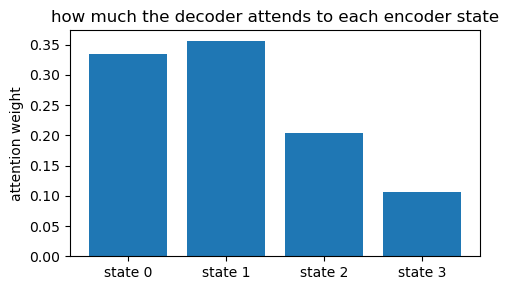

In [7]:
encoder_states = np.array([[1.0, 0.0],     # 4 encoder hidden states,
                           [0.8, 0.6],     # 2 dimensions each
                           [0.0, 1.0],
                           [-0.5, 0.5]])
decoder_state = np.array([0.9, 0.4])

scores = encoder_states @ decoder_state          # step 2: score each state
weights = np.exp(scores) / np.exp(scores).sum()  # step 3: softmax
context = weights @ encoder_states               # steps 4 + 5: weight and sum

print("scores           :", np.round(scores, 2))
print("attention weights:", np.round(weights, 3), " (sum =", weights.sum(), ")")
print("context vector   :", np.round(context, 3))

plt.figure(figsize=(5, 3))
plt.bar(range(len(weights)), weights)
plt.xticks(range(len(weights)), [f"state {i}" for i in range(len(weights))])
plt.ylabel("attention weight")
plt.title("how much the decoder attends to each encoder state")
plt.tight_layout(); plt.show()

The two encoder states most similar to the decoder state get the
largest weights, and the context vector is pulled toward them; the weights sum
to exactly 1. In a trained model the scoring is done by a learned alignment
network rather than a raw dot product, but the flow is the same.

**Transformers** stack these attention layers into a full encoder-decoder
architecture, dispensing with recurrence entirely. Introduced around 2017,
transformers have revolutionized neural machine translation (using ML to
predict the likelihood of a sequence of words) and are the architecture
behind **large language models**: GPT stands for *generative pretrained
transformer*. A nice interactive visualization of a transformer-based LLM is
at <https://bbycroft.net/llm>. For environmental time series, though,
transformers are not automatically the best choice: the more traditional
RNNs, LSTMs, and GRUs remain very useful.

## Graph neural networks

Not all data is a grid or a sequence. **Graph neural networks (GNNs)** are
deep learning architectures for **graph-structured data**: a set of nodes,
each with its own feature vector, connected by edges that encode arbitrary
relationships. We only touch on them here so you know they exist. With a GNN
you can make predictions at the node level (given a node's connectivity),
predict how nodes should be linked, or classify whole graphs.

Two climate examples:

- **GraphCast**, an ML-based numerical weather prediction model, treats each
  latitude, longitude, and height point as a node in a graph and adds
  *nested graphs at multiple resolutions*, so the model can capture not just
  local structure but long-range connectivity (the jet stream, or a sea
  surface temperature change in one basin affecting weather elsewhere). It
  performs on par with state-of-the-art numerical weather prediction.
- **Sparse sensor networks**: with air quality sensors scattered irregularly
  over a city, a GNN can learn spatial relationships between sites, so a
  prediction at one site can borrow information from its neighbors.

## Inductive bias in machine learning models

We can now line up all the deep learning architectures of this unit by the
assumption each one builds in:

| Data | Architecture | Inductive bias |
|---|---|---|
| Tabular features | Fully connected ANN | None: any input can relate to any output |
| Images, spatial maps | CNN | Spatial translation invariance: weights shared across space |
| Sequences, time series | RNN / LSTM / GRU | Time translation invariance: weights shared across time steps |
| Graphs, unstructured meshes | GNN | Relational: nodes treated according to their connectivity |

Choosing the architecture whose inductive bias matches the problem can
**significantly reduce the amount of training data needed and improve
predictive skill**. A recurrent model applied to a sequential task will beat
a fully connected network with many more weights, because the fully connected
network has to *learn* the structure the recurrent model gets for free.

These building blocks also **combine**. A CNN can encode each frame of a
spatial field into a hidden state that an LSTM then evolves through time
(CNN-LSTM, for spatio-temporal prediction such as forecasting how a map of a
variable changes). A GNN can do the same for sparse sensor sites, with an
LSTM handling the time dimension (GNN-LSTM, for time series prediction on
unstructured meshes). Picking an inductive bias is where our physical
intuition about a problem enters the architecture itself.